## librarys

In [52]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

### checking the device

In [53]:
device=torch.device("cuda/gpu"if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [54]:
data_dir_path=r"C:\dev\gcp_mlops_signiture_recog\notebooks\data"

In [55]:
class_names=os.listdir(data_dir_path)
class_names

['Forged', 'Original']

## load data

In [56]:
from torch.utils.data import DataLoader 
from torchvision.datasets import ImageFolder
from torchvision import transforms as T,datasets
from torchvision.utils import make_grid

### data augmentation and transformation

In [57]:
data_transform = T.Compose([

T.Resize(size=(224,224)), 
T.RandomRotation(degrees=(-20,+20)), 
T.ToTensor(), 
T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [58]:
data_transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [59]:
data=ImageFolder(root=data_dir_path,transform=data_transform)
data


Dataset ImageFolder
    Number of datapoints: 2640
    Root location: C:\dev\gcp_mlops_signiture_recog\notebooks\data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [60]:
total_count=len(data)

print(f"Total number of images in the dataset: {total_count}")
print(f"Number of classes in the dataset: {len(data.classes)}, and the classes are: --> {data.classes}")


Total number of images in the dataset: 2640
Number of classes in the dataset: 2, and the classes are: --> ['Forged', 'Original']


## Splitting the data

In [61]:
train_count = int(0.6* total_count)
valid_count = int(0.3 * total_count)
test_count = total_count - train_count - valid_count
train_data, val_data, test_data = torch.utils.data.random_split(data, (train_count, valid_count, test_count))

In [62]:
test_count

264

In [63]:
train_data[6]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044, -1.8044,

## Defining some functions

In [64]:
def show_image(image,label,get_denormalize = True):

    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406]) # chanel /hight /width
    std = torch.FloatTensor([0.229, 0.224, 0.225])

    if get_denormalize == True:
        image = image*std + mean
        image = np.clip(image,0,1)
        plt.imshow(image)
        plt.title(label)

    else:
        plt.imshow(image)
        plt.title(label)

def show_grid(image,title = None):

    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])

    image = image*std + mean
    image = np.clip(image,0,1)

    plt.figure(figsize=[15, 15])
    plt.imshow(image)
    if title != None:
        plt.title(title)

def accuracy(y_pred,y_true):
    y_pred = F.softmax(y_pred,dim =1)
    top_p,top_class = y_pred.topk(1,dim = 1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

In [65]:
img,label=train_data[6]

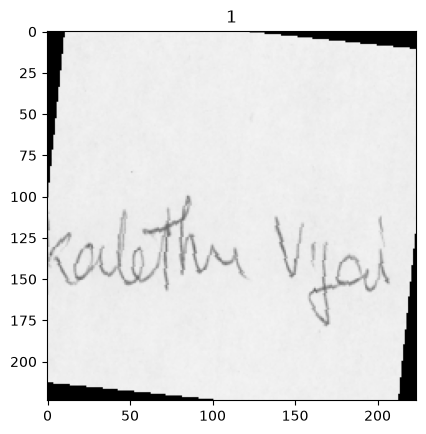

KeyboardInterrupt: 

In [ ]:
show_image(img,label)

## data loader

In [ ]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
print(f"No. of batches in trainloader:{len(trainloader)}")
print(f"No. of Total examples:{len(trainloader.dataset)}")

validationloader = DataLoader(val_data, batch_size=32, shuffle=True)
print(f"No. of batches in validationloader:{len(validationloader)}")
print(f"No. of Total examples:{len(validationloader.dataset)}")

testloader = DataLoader(test_data ,batch_size=32, shuffle=False)
print(f"No. of batches in testloader:{len(testloader)}")
print(f"No. of Total examples:{len(testloader.dataset)}")

No. of batches in trainloader:50
No. of Total examples:1584
No. of batches in validationloader:25
No. of Total examples:792
No. of batches in testloader:9
No. of Total examples:264


## training with transfer learning

In [86]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms

In [87]:
model = models.resnet18(pretrained=True)

c:\dev\gcp_mlops_signiture_recog\env\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\dev\gcp_mlops_signiture_recog\env\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [88]:
model.fc = nn.Sequential(
        nn.Dropout(0.1),
        nn.Linear(model.fc.in_features, len(data.classes))
        )

model = model.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [89]:
def train(model, criterion, optimizer, train_dataloader, test_dataloader):

    total_train_loss = 0
    total_test_loss = 0

    model.train()
    with tqdm(train_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'training')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output = model(images)

        loss = criterion(output, idxs)
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        model.eval()
        with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
            pbar.set_description(f'testing')
            for images, idxs in pbar:
                images = images.to(device, non_blocking=True)
                idxs = idxs.to(device, non_blocking=True)

                output = model(images)
                loss = criterion(output, idxs)
                total_test_loss += loss.item()
        train_acc = total_train_loss / len(train_data)
        test_acc = total_test_loss / len(val_data)
        print(f'Train loss: {train_acc :.4f} Test loss: {test_acc :.4f} ')

In [90]:
%time
epochs=10
for i in range(epochs):
    print(f"Epoch {i+1}/{epochs}")
    train(model, loss_fn, optimizer, trainloader, validationloader)

CPU times: total: 0 ns
Wall time: 0 ns
Epoch 1/10


training:   0%|          | 0/50 [00:00<?, ?batch/s]

Train loss: 0.0005 Test loss: 0.0246 
Epoch 2/10


Train loss: 0.0001 Test loss: 0.0218 
Epoch 3/10


Train loss: 0.0000 Test loss: 0.0130 
Epoch 4/10


...

Train loss: 0.0000 Test loss: 0.1125 
Epoch 7/10


Train loss: 0.0001 Test loss: 0.1685 
Epoch 8/10


Train loss: 0.0000 Test loss: 0.1185 
Epoch 9/10


Train loss: 0.0002 Test loss: 0.2197 
Epoch 10/10


Train loss: 0.0000 Test loss: 0.1078 


## model saving

In [91]:
pwd

'c:\\dev\\gcp_mlops_signiture_recog\\notebooks'

In [92]:
path=r"c:\\dev\\gcp_mlops_signiture_recog\\notebooks\\model.pt"
torch.save(model,path)

## model evaluation

In [93]:
model = torch.load(path, weights_only=False)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [94]:
def evaluate(model, criterion, optimizer, test_dataloader):
    total_test_loss = 0

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterion(output, idxs)
            total_test_loss += loss.item()

            test_acc = total_test_loss / len(val_data)
            print(f'Test loss: {test_acc :.4f} ')


In [95]:
evaluate(model, loss_fn, optimizer, testloader)

testing:  11%|█         | 1/9 [00:00<00:07,  1.07batch/s]

Test loss: 0.0051 


testing:  22%|██▏       | 2/9 [00:01<00:06,  1.11batch/s]

Test loss: 0.0122 


testing:  33%|███▎      | 3/9 [00:02<00:05,  1.13batch/s]

...

testing:  78%|███████▊  | 7/9 [00:05<00:01,  1.19batch/s]

Test loss: 0.0293 


testing:  89%|████████▉ | 8/9 [00:06<00:00,  1.17batch/s]

Test loss: 0.0306 


Test loss: 0.0371 


## prediction

In [96]:
label_names = data.classes

In [97]:
from PIL import Image

# Load the image and preprocess it
image = Image.open(r'C:\dev\gcp_mlops_signiture_recog\notebooks\data\Original\original_1_6.png')
preprocess = transforms.Compose([
    transforms.Resize(size = (224,224)),
    transforms.Grayscale(3),
    transforms. ToTensor()
])

image = preprocess(image)
image = image[:3]

# Convert the image to a PyTorch tensor and send it to the device
image = image.unsqueeze(0).to(device)

# Make the prediction
with torch.no_grad():
    logits = model(image)
    probs = torch.softmax(logits, dim=1)
    pred_label = torch.argmax(probs, dim=1)

# Print the prediction
print(f'Predicted label: {pred_label.item()}')

# Map the predicted label to the corresponding class name
predicted_class_name = label_names[pred_label.item()]

# Print the predicted class name
print(f'Predicted class name: {predicted_class_name}')

Predicted label: 1
Predicted class name: Original
